# visualization.ipynb

In [1]:
%matplotlib widget

import roadside as rs
import sqlite3
import textwrap
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import os
from icecream import ic
import numpy as np
import math


In [2]:
# root_dir = "/home/aubrey/Desktop/sam3-2026-01-31"
image_paths = ["example_images/08hs-palms-03-zglw-superJumbo.webp"]
text_prompts=["coconut palm tree"]
db_path = '/home/aubrey/Desktop/crbdd/test.db'

# Functions

## get_data_for_detections_table()

- comes from roadside.py.
- is here so that I can modify it.
- before moving back to roadside.py I need to remember to remove rs. preceding function calls.

## Required mods
- I need to find convexity defects on the crown of the coconut tree instead of the whole tree.

## Notes
- Looks like the best approach is to modify **get_data_for_detections_table()** so that the **hull_indices_string** field is for the crown and not the whole tree

In [3]:
def contour2binary_image(image_height, image_width, contour):
    img = np.zeros((image_height, image_width), dtype=np.uint8)
    return cv2.drawContours(img, [contour], -1, (255), thickness=cv2.FILLED)

# # Usage example
# sql =textwrap.dedent("""
#     select images.image_id, image_height, image_width, poly_wkt
#     from images, detections
#     where images.image_id=detections.image_id 
#     limit 1
#     """)
# df = pd.read_sql(sql, sqlite3.connect(db_path))
# for _, row in df.iterrows():
#     img = contour2binary_image(
#         image_height=row.image_height, 
#         image_width=row.image_width, 
#         contour=rs.wkt2contour(row.poly_wkt))

In [4]:
def gaussian_smooth(data, window_size):
    window = np.hanning(window_size) # Bell-shaped curve
    window /= window.sum()           # Normalize
    return np.convolve(data, window, mode='same')

# # Usage example
# sql =textwrap.dedent("""
#     select images.image_id, image_height, image_width, poly_wkt
#     from images, detections
#     where images.image_id=detections.image_id 
#     limit 1
#     """)
# df = pd.read_sql(sql, sqlite3.connect(db_path))
# for _, row in df.iterrows():
#     img = contour2binary_image(
#         image_height=row.image_height, 
#         image_width=row.image_width, 
#         contour=rs.wkt2contour(row.poly_wkt))

# Explanation

Restart here!

In [5]:
# def smooth_data(data, window_size):
#     # Create a uniform window (kernel)
#     window = np.ones(window_size) / window_size
#     # Convolve the data with the window
#     return np.convolve(data, window, mode='same')

# def gaussian_smooth(data, window_size):
#     window = np.hanning(window_size) # Bell-shaped curve
#     window /= window.sum()           # Normalize
#     return np.convolve(data, window, mode='same')

# rs.build_db(db_path, image_paths)

# Extract data for first detection from database
sql =textwrap.dedent("""
    select image_height, image_width, tree_wkt, crown_wkt
    from images, detections
    where images.image_id=detections.image_id 
    limit 1
    """)
df = pd.read_sql(sql, sqlite3.connect(db_path))
row = df.iloc[0]
ic(row)

ic| row: image_height                                                 2048
         image_width                                                  1366
         tree_wkt        POLYGON ((486 679, 486 684, 485 685, 485 688, ...
         crown_wkt       POLYGON ((486 679, 485 688, 479 695, 477 717, ...
         Name: 0, dtype: object


image_height                                                 2048
image_width                                                  1366
tree_wkt        POLYGON ((486 679, 486 684, 485 685, 485 688, ...
crown_wkt       POLYGON ((486 679, 485 688, 479 695, 477 717, ...
Name: 0, dtype: object

In [6]:
df.iloc[0].crown_wkt

'POLYGON ((486 679, 485 688, 479 695, 477 717, 487 729, 492 739, 490 742, 483 743, 481 747, 493 750, 495 753, 495 758, 486 768, 481 779, 474 784, 471 792, 470 804, 474 810, 484 817, 483 820, 478 821, 503 834, 505 836, 505 841, 495 851, 486 846, 476 836, 468 834, 464 838, 453 843, 450 855, 450 863, 453 871, 460 877, 474 882, 481 887, 488 883, 493 883, 503 893, 506 901, 506 911, 503 914, 505 923, 515 944, 516 951, 522 957, 553 957, 558 947, 563 931, 569 925, 577 922, 576 917, 563 911, 558 905, 558 892, 560 887, 576 873, 583 861, 583 857, 577 848, 579 836, 555 833, 550 829, 547 821, 547 806, 563 772, 563 767, 559 765, 556 761, 550 759, 541 759, 536 757, 521 758, 514 757, 510 754, 507 747, 503 725, 497 717, 495 704, 489 687, 488 679, 486 679))'

In [7]:
contour = rs.wkt2contour(row.tree_wkt)
mask = contour2binary_image(row.image_height, row.image_width, contour)
# for _, row in df.iterrows():
#     img = contour2binary_image(
#         image_height=row.image_height, 
#         image_width=row.image_width, 
#         contour=rs.wkt2contour(row.tree_wkt))

# mask = img.copy()

# row_sums is the number of white pixels (value=1) in each row of the mask
# row_indices is 0 ... n spanning the number of rows in the image
row_sums = np.sum(mask, axis=1)
row_indices = np.arange(mask.shape[0])

# normalized_row_sum is the proportion of mask pixels in each row
total_row_sums = np.sum(row_sums, dtype=np.float64)
ic(total_row_sums)
normalized_row_sums = row_sums / total_row_sums
ic(normalized_row_sums)
ic(type(normalized_row_sums))
ic(np.sum(normalized_row_sums))  # Should be close to 1.0

# Calculate the difference between consecutive row sums to find where the sum changes significantly
# to_begin=0 to keep the same length as row_sums
differences = np.ediff1d(normalized_row_sums, to_begin=0) 
gaussian_smoothed_differences = gaussian_smooth(differences, window_size=9)
ic(gaussian_smoothed_differences)

# cut_line estimates the y-value which separates the crown from the trunk
# the 10 rows of pixels at the bottom of the mask are ignored when finding cut_line
threshold = -0.00002
stop_search = -10
cut_line = np.max(np.where(gaussian_smoothed_differences[:stop_search] < threshold)).item()

# segment the crown by removing nonzero pixels from cut_line and below
# important: create a copy of mask instead of a view
crown_mask = mask.copy()
crown_mask[cut_line+1:, :] = 0
ic(crown_mask.shape);

# fit a polygon around the crown mask and convert to wkt text format for database storage
contours, _ = cv2.findContours(crown_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for cnt in contours:
    crown_poly = np.squeeze(cv2.approxPolyDP(curve=cnt, epsilon=1, closed=True))
crown_poly_wkt = rs.conv_poly_from_array_to_wkt(crown_poly)
ic(crown_poly_wkt)

ic| total_row_sums: np.float64(15262260.0)
ic| normalized_row_sums: array([          0,           0,           0, ...,  0.00080198,  0.00075185,  0.00075185], shape=(2048,))
ic| type(normalized_row_sums): <class 'numpy.ndarray'>
ic| np.sum(normalized_row_sums): np.float64(1.0)
ic| gaussian_smoothed_differences: array([          0,           0,           0, ..., -2.2615e-05,  -2.175e-05, -1.5484e-05], shape=(2048,))
ic| crown_mask.shape: (2048, 1366)
ic| crown_poly_wkt: 'POLYGON ((486 679, 485 688, 479 695, 477 717, 487 729, 492 739, 490 742, 483 743, 481 747, 493 750, 495 753, 495 758, 486 768, 481 779, 474 784, 471 792, 470 804, 474 810, 484 817, 483 820, 478 821, 503 834, 505 836, 505 841, 495 851, 486 846, 476 836, 468 834, 464 838, 453 843, 450 855, 450 863, 453 871, 460 877, 474 882, 481 887, 488 883, 493 883, 503 893, 506 901, 506 911, 503 914, 505 923, 515 944, 516 951, 522 957, 553 957, 558 947, 563 931, 569 925, 577 922, 576 917, 563 911, 558 905, 558 892, 560 887, 576 873, 58

'POLYGON ((486 679, 485 688, 479 695, 477 717, 487 729, 492 739, 490 742, 483 743, 481 747, 493 750, 495 753, 495 758, 486 768, 481 779, 474 784, 471 792, 470 804, 474 810, 484 817, 483 820, 478 821, 503 834, 505 836, 505 841, 495 851, 486 846, 476 836, 468 834, 464 838, 453 843, 450 855, 450 863, 453 871, 460 877, 474 882, 481 887, 488 883, 493 883, 503 893, 506 901, 506 911, 503 914, 505 923, 515 944, 516 951, 522 957, 553 957, 558 947, 563 931, 569 925, 577 922, 576 917, 563 911, 558 905, 558 892, 560 887, 576 873, 583 861, 583 857, 577 848, 579 836, 555 833, 550 829, 547 821, 547 806, 563 772, 563 767, 559 765, 556 761, 550 759, 541 759, 536 757, 521 758, 514 757, 510 754, 507 747, 503 725, 497 717, 495 704, 489 687, 488 679, 486 679))'

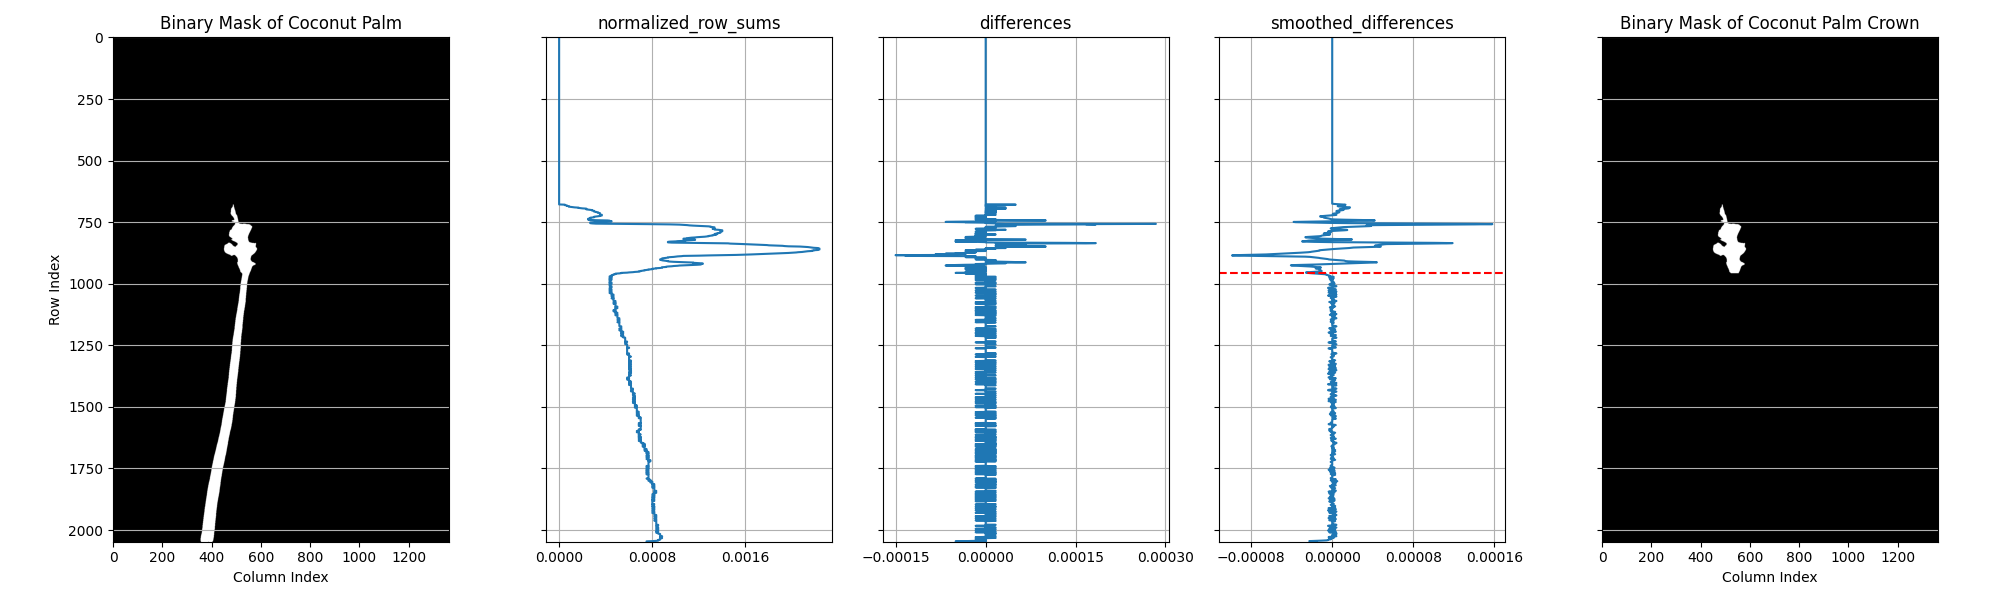

In [8]:
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(20, 6), sharey=True, gridspec_kw={'width_ratios': [3, 2, 2, 2, 3]})

# Plot the original binary mask
ax1.imshow(mask, cmap='gray')
ax1.set_title("Binary Mask of Coconut Palm")
ax1.set_ylabel("Row Index")
ax1.set_xlabel("Column Index")
ax1.yaxis.set_inverted(True)
ax1.xaxis.grid(False)
ax1.yaxis.grid(True)

ax2.plot(normalized_row_sums, row_indices)
ax2.set_title("normalized_row_sums")
ax2.grid(True)
ax2.xaxis.set_major_locator(plt.MaxNLocator(4))

ax3.plot(differences, row_indices)
ax3.set_title("differences")
ax3.grid(True)
ax3.xaxis.set_major_locator(plt.MaxNLocator(4))

ax4.plot(gaussian_smoothed_differences, row_indices)
ax4.set_title("smoothed_differences")
ax4.grid(True)
ax4.axhline(cut_line, color='red', linestyle='--')
ax4.xaxis.set_major_locator(plt.MaxNLocator(4))


ax5.imshow(crown_mask, cmap='gray')
ax5.set_title("Binary Mask of Coconut Palm Crown")
# ax5.set_ylabel("Row Index")
ax5.set_xlabel("Column Index")
# ax1.yaxis.set_inverted(True)
ax5.xaxis.grid(False)
ax5.yaxis.grid(True)

plt.tight_layout()
plt.show()

# Scan crown_mask for vcuts

In [9]:
# This is a MODIFIED copy of get_data_for_vcuts_table() from roadside.py

def get_data_for_vcuts_table(db_path: str, image_id: int)->pd.DataFrame:
    """ 
    Processes data for a single image. 
    Returns a pandas dataframe containing data to be added to the `vcuts` table.
    
    Presently, all data are sourced from the database. Undoubtedly, this is inefficient. 
    In the future, I will refactor to source data from the results_cpu variable that is 
    used for populating the `images` and `detections` tables.
    """
    
    # get input data from the images and detections tables
    sql = f""" 
    SELECT image_path, detection_id, crown_wkt
    FROM images, detections
    WHERE images.image_id=detections.image_id AND images.image_id={image_id}
    """
    df_input = pd.read_sql(sql, sqlite3.connect(db_path))
    ic(df_input)

    data_list = [] # list of dicts to be converted to dataframe for insertion into vcuts table
    for i, r in df_input.iterrows():
        crown_contour = rs.wkt2contour(r.crown_wkt)
        hull_indices = cv2.convexHull(crown_contour, returnPoints=False)
        try:
            defects = cv2.convexityDefects(crown_contour, hull_indices)
        except Exception as e:
            print(f"Error occurred while calculating convexity defects for row {i}: {e}")
            continue
        # ic(defects)
        # ic(defects.shape)
        
        # process defects
        for j, defect in enumerate(defects):
            
            start_idx, end_idx, far_idx, depth = defect[0]
            start_point = crown_contour[start_idx][0]
            end_point = crown_contour[end_idx][0]
            far_point = crown_contour[far_idx][0]
            
            # calculate length of all sides of triangle in pixels
            a = math.sqrt((end_point[0] - start_point[0])**2 + (end_point[1] - start_point[1])**2)
            b = math.sqrt((far_point[0] - start_point[0])**2 + (far_point[1] - start_point[1])**2)
            c = math.sqrt((end_point[0] - far_point[0])**2 + (end_point[1] - far_point[1])**2)
            
            # calculate depth of the convexity defect using Heron's formula in pixels
            # equals distance between far_point point and base of the triangle (the `a` side) 
            s = (a+b+c)/2
            area = math.sqrt(s*(s-a)*(s-b)*(s-c))
            depth = (2*area)/a # depth is the height of the triangle, which is the distance from the far point to the line formed by the start and end points
            
            # calculate the angle of the defect in degrees using the cosine rule
            angle = math.degrees(math.acos((b**2 + c**2 - a**2)/(2*b*c)))
            # ic(i, d, angle, start, far, end)

            data_dict = {
                'detection_id': r.detection_id,
                'start_x': start_point[0],
                'start_y': start_point[1],
                'far_x': far_point[0],
                'far_y': far_point[1],
                'end_x': end_point[0],
                'end_y': end_point[1],
                'depth': depth,
                'degrees': angle
            }
            data_list.append(data_dict)
        df_output = pd.DataFrame(data_list)
    return df_output

# Usage example:

# df_vcuts = get_data_for_vcuts_table(db_path=db_path, image_id=1)


In [39]:
# Get all vcuts records for the first detection in the the database
df_vcuts = get_data_for_vcuts_table(db_path=db_path, image_id=1)
df_vcuts = df_vcuts.query('detection_id==1')

# crown_contour = rs.wkt2contour(row.crown_wkt)
# crown_mask = contour2binary_image(row.image_height, row.image_width, crown_contour)

# # Convert 1-channel mask (GRAY) to 3-channel (BGR) so that we can draw colored lines
img_crown_mask = cv2.cvtColor(crown_mask, cv2.COLOR_GRAY2RGB)

for r in df_vcuts.itertuples():
    cv2.line(img=img_crown_mask, pt1=(r.start_x, r.start_y), pt2=(r.end_x, r.end_y), color=(0,255,0), thickness=2)
    cv2.line(img=img_crown_mask, pt1=(r.start_x, r.start_y), pt2=(r.far_x, r.far_y), color=(255,0,0), thickness=2)
    cv2.line(img=img_crown_mask, pt1=(r.end_x, r.end_y),     pt2=(r.far_x, r.far_y), color=(255,0,0), thickness=2)
    




# hull = cv2.convexHull(crown_contour)
# # # Draw original contour in green
# # cv2.drawContours(my_img, [cnt], 0, (0, 255, 0), 1)
# # # Draw convex hull in red
# # cv2.drawContours(my_img, [hull], 0, (0, 0, 255), 1)

# cnt = crown_contour
# hull_indices = cv2.convexHull(cnt, returnPoints=False)
# defects = cv2.convexityDefects(cnt, hull_indices)

# defects_list = []
# for i in range(defects.shape[0]):
#     s, e, f, d = defects[i,0]
#     start = tuple(cnt[s][0])
#     end = tuple(cnt[e][0])
#     far = tuple(cnt[f][0])
#     defects_list.append({'start_x': start[0], 'start_y': start[1], 'end_x': end[0], 'end_y': end[1], 'far_x': far[0], 'far_y': far[1]})
# df_defects = pd.DataFrame(defects_list)
# ic(df_defects)
    
#     # # Optional: Filter by depth to ignore small noise
#     # if d > 1:
#     #     cv2.line(img=my_img, pt1=start, pt2=far, color=(255, 0, 0), thickness=3)
#     #     cv2.line(img=my_img, pt1=end, pt2=far, color=(255, 0, 0), thickness=3)
#     #     # cv2.circle(img=my_img, center=far, radius=5, color=(0, 0, 255), thickness=-1)

# for d in defects_list:
#     cv2.line(
#         img=crown_mask, 
#         pt1=(d['start_x'], d['start_y']), 
#         pt2=(d['end_x'],   d['end_y']), 
#         color=(0,255,0), 
#         thickness=2)
#     cv2.line(
#         img=crown_mask, 
#         pt1=(d['start_x'], d['start_y']), 
#         pt2=(d['far_x'],   d['far_y']), 
#         color=(255,0,0), 
#         thickness=2)
#     cv2.line(
#         img=crown_mask, 
#         pt1=(d['end_x'], d['end_y']), 
#         pt2=(d['far_x'],   d['far_y']), 
#         color=(255,0,0), 
#         thickness=2)

ic| df_input:                                           image_path  detection_id  \
              0  example_images/08hs-palms-03-zglw-superJumbo.webp             1   
              1  example_images/08hs-palms-03-zglw-superJumbo.webp             2   
              
                                                         crown_wkt  
              0  POLYGON ((486 679, 485 688, 479 695, 477 717, ...  
              1  POLYGON ((1092 1526, 1090 1522, 1068 1510, 106...  


In [34]:
for r in df_vcuts.itertuples():
    ic(r.start_x, r.start_y)

ic| r.start_x: 486, r.start_y: 679
ic| r.start_x: 479, r.start_y: 695
ic| r.start_x: 453, r.start_y: 871
ic| r.start_x: 553, r.start_y: 957
ic| r.start_x: 577, r.start_y: 922
ic| r.start_x: 583, r.start_y: 857
ic| r.start_x: 579, r.start_y: 836
ic| r.start_x: 563, r.start_y: 767


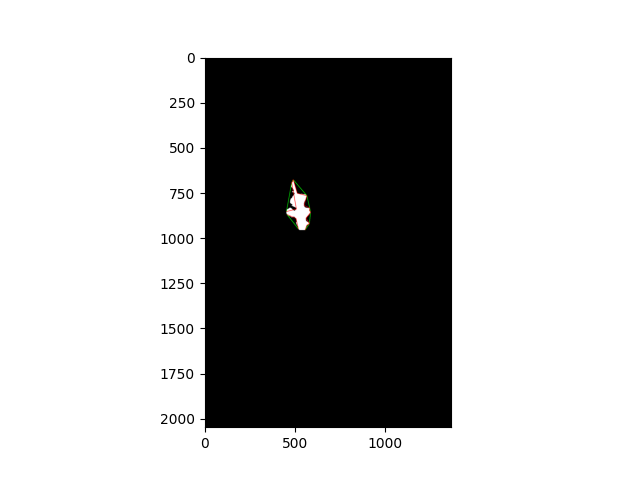

In [40]:
fig, ax1 = plt.subplots(1, 1)
ax1.imshow(img_crown_mask)
plt.show()

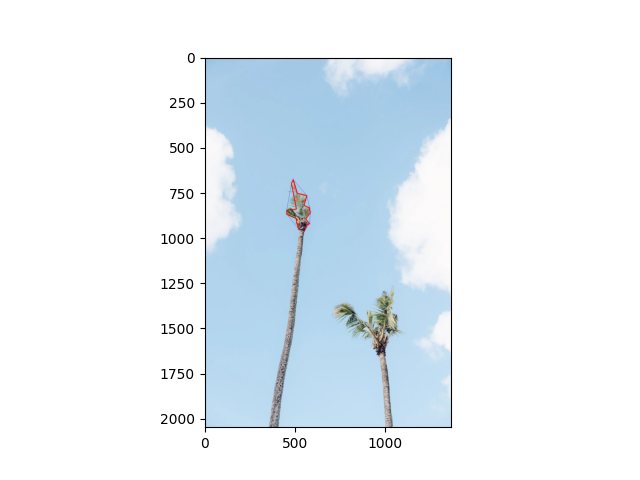

In [12]:
my_img = cv2.imread(image_paths[0])
my_img = cv2.cvtColor(my_img, cv2.COLOR_RGB2BGR)
contours, hierarchy = cv2.findContours(crown_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
for cnt in contours:
    hull = cv2.convexHull(cnt)
    # Draw original contour in green
    cv2.drawContours(my_img, [cnt], 0, (0, 255, 0), 1)
    # Draw convex hull in red
    cv2.drawContours(my_img, [hull], 0, (0, 0, 255), 1)
    
    hull_indices = cv2.convexHull(cnt, returnPoints=False)
    defects = cv2.convexityDefects(cnt, hull_indices)
    
    for i in range(defects.shape[0]):
        s, e, f, d = defects[i,0]
        start = tuple(cnt[s][0])
        end = tuple(cnt[e][0])
        far = tuple(cnt[f][0])
        
        # Optional: Filter by depth to ignore small noise
        if d > 1:
            cv2.line(img=my_img, pt1=start, pt2=far, color=(255, 0, 0), thickness=3)
            cv2.line(img=my_img, pt1=end, pt2=far, color=(255, 0, 0), thickness=3)
            # cv2.circle(img=my_img, center=far, radius=5, color=(0, 0, 255), thickness=-1)
    
fig, ax1 = plt.subplots(1, 1)
ax1.imshow(my_img)
plt.show()


In [13]:
ic(start, end, far)
len(contours)

ic| start: (np.int32(563), np.int32(767))
    end: (np.int32(488), np.int32(679))
    far: (np.int32(510), np.int32(754))


1

NameError: name 'ymin' is not defined

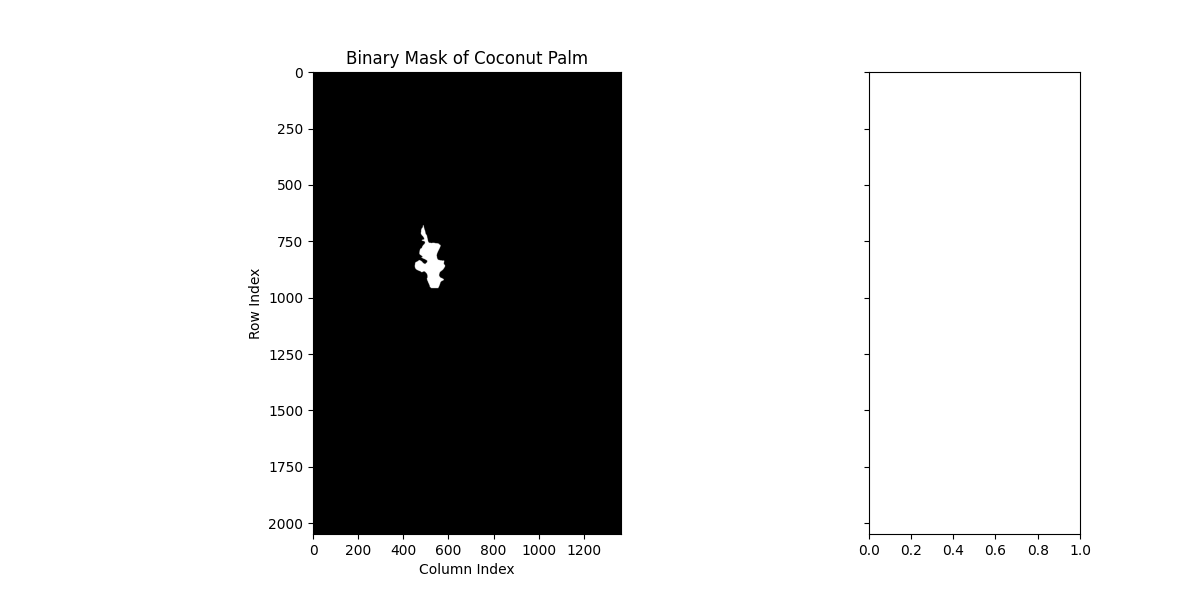

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True, 
    gridspec_kw={'width_ratios': [3, 1]})

# Plot the original binary mask
ax1.imshow(crown_mask, cmap='gray')
ax1.set_title("Binary Mask of Coconut Palm")
ax1.set_ylabel("Row Index")
ax1.set_xlabel("Column Index")
ax1.set_ylim(ymin, ymax)
ax1.set_xlim(xmin, xmax)
ax1.yaxis.set_inverted(True)


# Plot the row sums
# We plot (row_sums) on X and (row_indices) on Y to align with the image
# ax2.plot(row_sums, row_indices)
# ax2.set_title("Row Sums")
# ax2.set_xlabel("Sum Value (pixels)")
# ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np

# 1. Load and process image
img = cv2.imread('shape.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 127, 255, 0)

# 2. Find contours
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# 3. Calculate and draw hull for each contour
for cnt in contours:
    hull = cv2.convexHull(cnt)
    # Draw original contour in green
    cv2.drawContours(img, [cnt], 0, (0, 255, 0), 2)
    # Draw convex hull in red
    cv2.drawContours(img, [hull], 0, (0, 0, 255), 3)

cv2.imshow('Convex Hull', img)
cv2.waitKey(0)


In [ ]:
nonzero_row_indices = np.where(crown_mask.any(axis=1))[0]
ic(nonzero_row_indices)
nonzero_col_indices = np.where(crown_mask.any(axis=0))[0]
ic(nonzero_col_indices)

ymin = nonzero_row_indices[0].item()
ymax = nonzero_row_indices[-1].item()

xmin = nonzero_col_indices[0].item()
xmax = nonzero_col_indices[-1].item()

In [ ]:
# import cv2
# import numpy as np

# # Load and binarize image
# img = cv2.imread('image.png')
# gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# ret, thresh = cv2.threshold(gray, 127, 255, 0)

# Find contours
# contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours, _ = cv2.findContours(crown_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    # Calculate convex hull
    hull = cv2.convexHull(cnt)
    
    # Draw original contour (green) and hull (red)
    cv2.drawContours(img, [cnt], 0, (0, 255, 0), 2)
    cv2.drawContours(img, [hull], 0, (0, 0, 255), 3)

cv2.imshow('Convex Hull', img)
cv2.waitKey(0)


In [ ]:
# Plot the original binary mask
ax1.imshow(crown_mask, cmap='gray')
ax1.set_title("Binary Mask of Coconut Palm")
ax1.set_ylabel("Row Index")
ax1.set_xlabel("Column Index")
ax1.yaxis.set_inverted(True)


In [ ]:
ic(type(row_sums))  
delta = np.diff(row_sums.astype(np.int32))
ic(type(delta))
plt.plot(delta
plt.title("Difference of Row Sums")
plt.xlabel("Row Index")
plt.ylabel("Difference in Sum Value")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

# Causes huge numbers
a = np.array([5, 10, 2, 8], dtype=np.uint8)
print(np.diff(a)) 
# Output: [  5 246   6] (10-2 is 8, but 2-10 wraps)

# Correct approach
b = a.astype(np.int16)
print(np.diff(b)) 
# Output: [ 5 -8  6]


In [ ]:
diff